In [2]:
import tensorflow as tnf
import matplotlib.pyplot as plt
import cv2
import numpy as np

In [3]:
data_dir="C:/Users/shars/Downloads/Crops"

In [28]:
data=tnf.keras.utils.image_dataset_from_directory(data_dir,batch_size=32,label_mode='categorical')

Found 22787 files belonging to 15 classes.


In [29]:
data.class_names

['Pepper,_bell___Bacterial_spot',
 'Pepper,_bell___healthy',
 'Potato___Early_blight',
 'Potato___Late_blight',
 'Potato___healthy',
 'Tomato___Bacterial_spot',
 'Tomato___Early_blight',
 'Tomato___Late_blight',
 'Tomato___Leaf_Mold',
 'Tomato___Septoria_leaf_spot',
 'Tomato___Spider_mites Two-spotted_spider_mite',
 'Tomato___Target_Spot',
 'Tomato___Tomato_Yellow_Leaf_Curl_Virus',
 'Tomato___Tomato_mosaic_virus',
 'Tomato___healthy']

In [8]:
batch=data.as_numpy_iterator().next()
batch

(array([[[[152., 138., 153.],
          [153., 139., 154.],
          [150., 136., 151.],
          ...,
          [193., 181., 193.],
          [196., 184., 196.],
          [191., 179., 191.]],
 
         [[153., 139., 154.],
          [153., 139., 154.],
          [151., 137., 152.],
          ...,
          [192., 180., 192.],
          [193., 181., 193.],
          [189., 177., 189.]],
 
         [[155., 141., 156.],
          [155., 141., 156.],
          [152., 138., 153.],
          ...,
          [189., 177., 189.],
          [188., 176., 188.],
          [189., 177., 189.]],
 
         ...,
 
         [[143., 121., 134.],
          [141., 119., 132.],
          [151., 129., 142.],
          ...,
          [145., 131., 144.],
          [135., 121., 134.],
          [191., 177., 190.]],
 
         [[138., 116., 129.],
          [145., 123., 136.],
          [123., 101., 114.],
          ...,
          [173., 159., 172.],
          [158., 144., 157.],
          [113.,  99., 112.

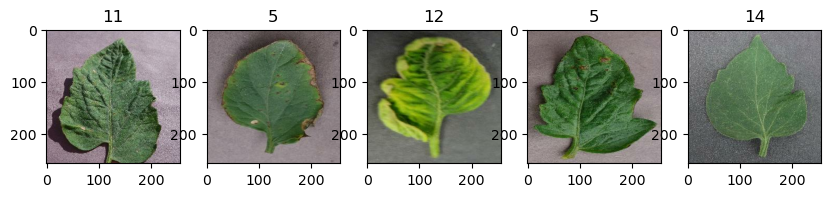

In [11]:
fig,ax=plt.subplots(1,5,figsize=(10,10))
for ind,image in enumerate(batch[0][:5]):
    ax[ind].imshow(image.astype(int))
    ax[ind].set_title(np.argmax(batch[1][ind]))

In [6]:
data=data.map(lambda x,y:(x/255.0,y))

In [7]:
len(data)

713

In [8]:
train_size=500
test_size=150
val_size=63

In [9]:
train=data.take(train_size)
val=data.skip(train_size).take(val_size)
test=data.skip(train_size+val_size).take(test_size)

In [10]:
from tensorflow.keras.models import Sequential
from tensorflow.keras.layers import Conv2D,MaxPooling2D,Dense,Flatten

In [11]:
model=Sequential()

In [12]:
model.add(Conv2D(16,(3,3),1,activation='relu',input_shape=(256,256,3)))
model.add(MaxPooling2D())

model.add(Conv2D(32,(3,3),1,activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(64,(3,3),1,activation='relu'))
model.add(Conv2D(128,(3,3),1,activation='relu'))
model.add(MaxPooling2D())

model.add(Conv2D(128,(3,3),1,activation='relu'))
model.add(MaxPooling2D())

model.add(Flatten())

model.add(Dense(512,activation='relu'))
model.add(Dense(64,activation='relu'))
model.add(Dense(15,activation='softmax'))

C:\Users\shars\anaconda3\lib\site-packages\keras\src\layers\convolutional\base_conv.py:107: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


In [13]:
model.compile(optimizer='adam',loss='categorical_crossentropy',metrics=['accuracy'])

In [14]:
model.summary()

Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━┓
┃ Layer (type)                         ┃ Output Shape                ┃         Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                      │ (None, 254, 254, 16)        │             448 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d (MaxPooling2D)         │ (None, 127, 127, 16)        │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_1 (Conv2D)                    │ (None, 125, 125, 32)        │           4,640 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_1 (MaxPooling2D)       │ (None, 62, 62, 32)          │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_2 (Conv2D)                    │ (None, 60, 60, 64)          │          18,496 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_3 (Conv2D)                    │ (None, 58, 58, 128)         │          73,856 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_2 (MaxPooling2D)       │ (None, 29, 29, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ conv2d_4 (Conv2D)                    │ (None, 27, 27, 128)         │         147,584 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ max_pooling2d_3 (MaxPooling2D)       │ (None, 13, 13, 128)         │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ flatten (Flatten)                    │ (None, 21632)               │               0 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense (Dense)                        │ (None, 512)                 │      11,076,096 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_1 (Dense)                      │ (None, 64)                  │          32,832 │
├──────────────────────────────────────┼─────────────────────────────┼─────────────────┤
│ dense_2 (Dense)                      │ (None, 15)                  │             975 │
└──────────────────────────────────────┴─────────────────────────────┴─────────────────┘

 Total params: 11,354,927 (43.32 MB)

 Trainable params: 11,354,927 (43.32 MB)

 Non-trainable params: 0 (0.00 B)

In [15]:
from tensorflow.keras.callbacks import EarlyStopping

In [16]:
early_stopping=EarlyStopping(monitor='val_loss',patience=3,restore_best_weights=True)

In [17]:
try:
    history=model.fit(train,validation_data=val,epochs=10,callbacks=[early_stopping])
except KeyboardInterrupt:
    print("\nTraining interrupted")

Epoch 1/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 375s 745ms/step - accuracy: 0.4219 - loss: 1.8385 - val_accuracy: 0.7485 - val_loss: 0.7307
Epoch 2/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 387s 773ms/step - accuracy: 0.7801 - loss: 0.6606 - val_accuracy: 0.7753 - val_loss: 0.6317
Epoch 3/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 373s 747ms/step - accuracy: 0.8705 - loss: 0.3803 - val_accuracy: 0.8795 - val_loss: 0.3552
Epoch 4/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 362s 723ms/step - accuracy: 0.9291 - loss: 0.2108 - val_accuracy: 0.8373 - val_loss: 0.5263
Epoch 5/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 363s 726ms/step - accuracy: 0.9418 - loss: 0.1699 - val_accuracy: 0.8715 - val_loss: 0.4409
Epoch 6/10
500/500 ━━━━━━━━━━━━━━━━━━━━ 365s 730ms/step - accuracy: 0.9684 - loss: 0.1047 - val_accuracy: 0.9008 - val_loss: 0.3739


In [18]:
model.save("model.h5")

In [19]:
history.history

{'accuracy': [0.5808125138282776,
  0.8039374947547913,
  0.8865625262260437,
  0.9296875,
  0.9498124718666077,
  0.9665625095367432],
 'loss': [1.310505986213684,
  0.5813196897506714,
  0.3330056369304657,
  0.20833921432495117,
  0.148112490773201,
  0.1074933260679245],
 'val_accuracy': [0.7485119104385376,
  0.7752976417541504,
  0.8794642686843872,
  0.8373016119003296,
  0.8715277910232544,
  0.9007936716079712],
 'val_loss': [0.7306938171386719,
  0.631704568862915,
  0.35519489645957947,
  0.5263174176216125,
  0.44092831015586853,
  0.37391701340675354]}

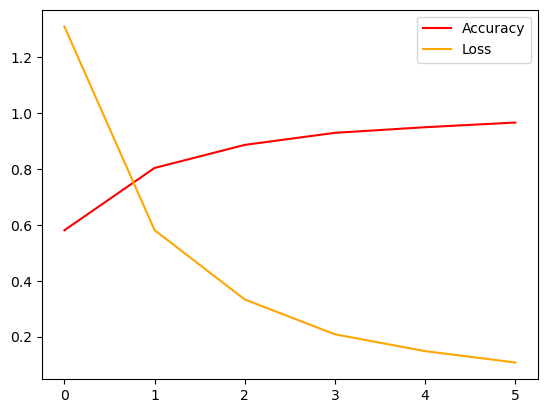

In [20]:
plt.plot(history.history['accuracy'],color='red',label='Accuracy')
plt.plot(history.history['loss'],color='orange',label='Loss')
plt.legend()
plt.show()

In [21]:
accuracy=model.evaluate(test)

150/150 ━━━━━━━━━━━━━━━━━━━━ 39s 219ms/step - accuracy: 0.8795 - loss: 0.3540


In [31]:
from tensorflow.keras.metrics import Precision,Recall,CategoricalAccuracy

In [32]:
pre=Precision()
rec=Recall()
acc=CategoricalAccuracy()

In [33]:
x_test=[]
y_test=[]
for batch in test.as_numpy_iterator():
    x,y=batch
    y=y.astype(int)
    x_test.append(x)
    y_test.append(y)

In [34]:
x_test=np.concatenate(x_test)
y_test=np.concatenate(y_test)

In [35]:
yhat=model.predict(x_test)

150/150 ━━━━━━━━━━━━━━━━━━━━ 31s 198ms/step


In [36]:
pre.update_state(y_test,yhat)
rec.update_state(y_test,yhat)
acc.update_state(y_test,yhat)

In [37]:
pre.result().numpy(),rec.result().numpy(),acc.result().numpy()

(0.8979277, 0.85369945, 0.8744498)

In [38]:
from sklearn.metrics import confusion_matrix as cm

In [39]:
y_test_labels=np.argmax(y_test,axis=1)

In [40]:
y_test_labels

array([ 0, 12, 12, ..., 14, 11,  9], dtype=int64)

In [41]:
y=np.argmax(yhat,axis=1)
y

array([ 9, 12, 12, ..., 14, 10,  9], dtype=int64)

In [83]:
matrix=cm(y_test_labels,y)

In [84]:
import pandas as pd
df=pd.DataFrame(matrix)
df

,0,1,2,3,4,5,6,7,8,9,10,11,12,13,14
0,172,14,1,0,0,0,1,4,1,11,3,0,0,0,0
1,6,267,0,1,5,0,1,1,0,1,0,0,1,0,0
2,4,0,179,12,0,0,0,0,0,8,0,0,0,0,0
3,5,2,0,181,3,1,4,7,0,4,0,0,5,0,0
4,0,8,0,3,21,0,0,0,0,0,1,1,0,0,0
5,0,0,0,1,0,386,18,5,0,4,0,1,32,0,0
6,4,1,0,9,0,4,138,7,0,10,6,4,5,0,0
7,7,3,2,25,1,1,21,333,6,18,1,0,0,0,2
8,0,1,0,0,0,0,5,3,173,13,6,0,1,0,1
9,10,5,0,6,1,3,8,7,30,289,3,12,3,3,6


In [43]:
from sklearn.metrics import classification_report
report = classification_report(y_test_labels, y)

In [44]:
print(report)

              precision    recall  f1-score   support

           0       0.82      0.83      0.83       207
           1       0.88      0.94      0.91       283
           2       0.98      0.88      0.93       203
           3       0.76      0.85      0.80       212
           4       0.62      0.62      0.62        34
           5       0.97      0.86      0.92       447
           6       0.67      0.73      0.70       188
           7       0.90      0.79      0.84       420
           8       0.80      0.85      0.83       203
           9       0.80      0.75      0.77       386
          10       0.81      0.87      0.84       361
          11       0.82      0.82      0.82       314
          12       0.94      0.99      0.96      1081
          13       0.92      0.79      0.85        84
          14       0.97      0.93      0.95       348

    accuracy                           0.87      4771
   macro avg       0.84      0.83      0.84      4771
weighted avg       0.88   

In [47]:
from sklearn.metrics import f1_score

In [51]:
f1 = f1_score(y_test_labels, y, average='weighted')
f1

0.8744683631159393

In [45]:
import seaborn as sns

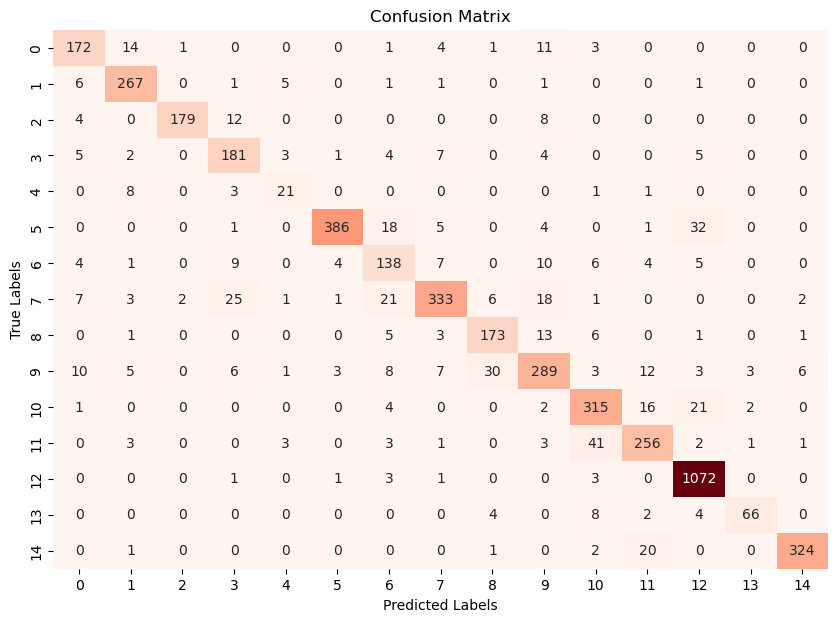

In [46]:
plt.figure(figsize=(10, 7))
sns.heatmap(matrix, annot=True, fmt="d", cmap="Reds", cbar=False)
plt.xlabel('Predicted Labels')
plt.ylabel('True Labels')
plt.title('Confusion Matrix')
plt.show()